<a href="https://colab.research.google.com/github/Emil-888/Data-Science/blob/main/copia_de_08_validacion_metricas_overfitting_para_completar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **Versión para completar.** Validación, métricas y overfitting.
> Solución: `08_validacion_metricas_overfitting.ipynb`.
> Teoría: `08_teoria_validacion_metricas_overfitting.pdf`.
> CSV: `Penguins.csv`.

# UDECATALUNA — para completar
_________________________________

Tema: Modelos de Aprendizaje — **Validación, métricas y overfitting**
_________________________________

**Dataset:** `Penguins.csv`  
**Modelo de la demo:** `DecisionTreeClassifier` (la profundidad hace visible el sobreajuste)

## Objetivo

Al terminar vas a poder:

* Decir qué es **overfitting** y qué es **underfitting**, con un número de train y uno de test.
* Separar **train / validación / test** y no gastar el test eligiendo `max_depth`.
* Usar **validación cruzada** en el train.
* Elegir la métrica según el problema (las de siempre: MAE/R² o accuracy/matriz/reporte).
* Resolver 10 ejercicios (todos están hechos acá).

> Un modelo que se saca 10 en el train y 6 en el test **no aprendió el fenómeno**. Memorizó las filas.

**Reglas de esta clase**

1. El test no se toca para elegir hiperparámetros.
2. Train alto y test bajo = overfitting. Train y test bajos = underfitting.
3. La métrica del train **no** es la que se publica.
4. El código va seguido. Sin funciones extra.

| Palabra | Qué es |
|---|---|
| **Underfitting** | El modelo es demasiado simple. Falla en train y en test. |
| **Overfitting** | El modelo es demasiado flexible. Brilla en train y cae en test. |
| **Validación** | Un pedazo del train (o pliegues) para elegir diales **sin** mirar el test. |
| **Métrica** | El número con el que declarás si ganó. Tiene que coincidir con la pregunta. |

In [ ]:
# PASO 1 — Entorno: warnings, plt, np, pd, sns, display.
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (10, 4)

### Bloque 1 — Datos (los de siempre)

Clasificamos **especie**. El árbol con `max_depth` grande puede aislar casi cada pingüino del train: accuracy 1.00 ahí, y menos afuera.

In [ ]:
# PASO 2 — Cargar Penguins.csv, dropna, rename (como en el repaso).
raw = pd.read_csv("/content/Penguins.csv")
df = raw.dropna().copy()
df = df.rename(columns={
    "species": "especie",
    "island": "isla",
    "bill_length_mm": "pico_largo",
    "bill_depth_mm": "aleta",
    "flipper_length_mm": "pico_ancho",
    "body_mass_g": "peso",
    "sex": "sexo"
})
print(len(df), "filas")
display(df.head())

333 filas


,especie,isla,pico_largo,aleta,pico_ancho,peso,sexo
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [ ]:
# PASO 3 — Split stratify 0.25. Guardá el test. No lo uses para elegir depth.
from sklearn.model_selection import train_test_split

num_c = ["pico_largo", "aleta", "pico_ancho", "peso"]
cat_c = ["isla", "sexo"]


x = df[num_c + cat_c]
y = df["especie"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42, stratify=y
)
print("Train:", len(x_train), "| Test:", len(x_test))

Train: 249 | Test: 84


### Bloque 2 — La foto del overfitting

Entrenamos el **mismo** árbol con `max_depth` 1, 2, 3, 5, 8, 12.  
Anotamos accuracy en **train** y en **test**. El test acá es solo para **ver** la curva, no para elegir todavía.

,max_depth,acc_train,acc_test,brecha
0,1,0.79,0.77,0.01
1,2,0.96,0.95,0.01
2,3,0.98,0.96,0.02
3,4,0.99,0.98,0.02
4,5,1.00,0.93,0.07
5,6,1.00,0.93,0.07
6,8,1.00,0.93,0.07
7,12,1.00,0.93,0.07


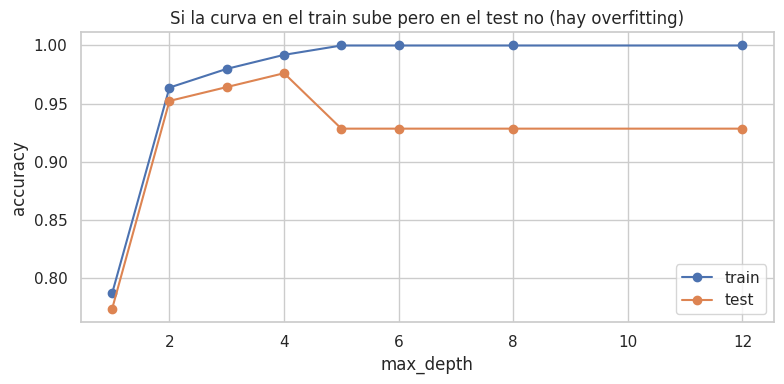

In [ ]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (10, 4)
# PASO 4 — Tabla max_depth 1,2,3,5,8,12: acc train y test + gráfico de las dos curvas.
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

def arbol(depth):
  return Pipeline([
    ("pre", ColumnTransformer([
      ("num", "passthrough", num_c),
      ("cat", OneHotEncoder(handle_unknown="ignore"), cat_c)
    ])),
    ("clf", DecisionTreeClassifier(max_depth=depth, random_state=42))
  ])

filas = []
for d in [1,2,3,4,5,6,8,12]:
  m = arbol(d)
  m.fit(x_train, y_train)
  filas.append({
      "max_depth": d,
      "acc_train": accuracy_score(y_train, m.predict(x_train)),
      "acc_test": accuracy_score(y_test, m.predict(x_test))
  })
curva = pd.DataFrame(filas)
curva["brecha"] = (curva ["acc_train"] - curva ["acc_test"]).round(2)
display(curva.round(2))

plt.figure(figsize=(8, 4))
plt.plot(curva["max_depth"], curva["acc_train"], marker = "o", label="train")
plt.plot(curva["max_depth"], curva["acc_test"], marker = "o", label="test")
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.title("Si la curva en el train sube pero en el test no (hay overfitting)")
plt.legend()
plt.tight_layout()
plt.show()



**Cómo se lee**

* Depth 1: train y test bajos y juntos → **underfitting** (un solo if no alcanza).
* Depth 3: los dos altos y cerca → zona sana.
* Depth 12: train en 1.00, test más abajo → **overfitting** (memorizó).

La **brecha** train − test es el termómetro. Grande = sobreajuste.

LA COSA ACÁ ES QUE YO ME QUEDO CON EL QUE MENOR BRECHA TIENE ENTRE acc_train y acc_test

### Bloque 3 — Validación: un pedazo del train, no el test

Idea: partir el train otra vez.

* **train interno** — ahí se ajustan los cortes del árbol.
* **validación** — ahí se elige `max_depth`.
* **test** — se mira **una vez**, con el depth ganador.

Así el test no participó de la elección.

In [ ]:
# PASO 5 — Partí el TRAIN en train interno y val (0.25, stratify).
# Elegí depth con acc_val. Reentrená con TODO el train. Accuracy en test una vez.

x_tr, x_val, y_tr, y_val = train_test_split(
    x_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)
print("Train interno:", len(x_tr), "| Validacion:", len(x_val), "Test original:", len(x_test))
candi = []

for d in [1, 2, 3, 4, 5, 6, 8, 12]:
  m = arbol(d)
  m.fit(x_tr, y_tr)
  candi.append({
      "max_depth": d,
      "acc_train": accuracy_score(y_tr, m.predict(x_tr)),
      "acc_val": accuracy_score(y_val, m.predict(x_val))
  })

tab_val = pd.DataFrame(candi)
display(tab_val.round(2))

best_val = tab_val["acc_val"].max()
d_star = int(tab_val.loc[tab_val["acc_val"] == best_val, "max_depth"].min())
print("Profundidad ganadora en Validacion:", d_star, "si empatan, la mas chica")

final = arbol(d_star)
final.fit(x_train, y_train)

print("Accuracy en test:", round(accuracy_score(y_test, final.predict(x_test)), 3
))

Train interno: 186 | Validacion: 63 Test original: 84


,max_depth,acc_train,acc_val
0,1,0.79,0.78
1,2,0.97,0.94
2,3,0.99,0.94
3,4,1.00,0.97
4,5,1.00,0.97
5,6,1.00,0.97
6,8,1.00,0.97
7,12,1.00,0.97


Profundidad ganadora en Validacion: 4 si empatan, la mas chica
Accuracy en test: 0.976


### Bloque 4 — Validación cruzada (sin gastar un val fijo)

Un solo corte train/val depende del azar. **CV**: 5 pedazos del **train**. Cada vez uno es val y los otros entrenan. Se reporta media ± desvío.

El test **no** entra a los pliegues.

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_filas = []

for d in [1, 2, 3, 5, 6, 8, 12]:
  scores = cross_val_score(arbol(d), x_train, y_train, cv = cv, scoring = "accuracy")
  cv_filas.append({
      "max_depth": d,
      "cv_mean": scores.mean(),
      "cv_std": scores.std(),
      "pliegues": np.round(scores, 3).tolist(),
  })

  tab_cv = pd.DataFrame(cv_filas)
  display(tab_cv.round(3))

  best_cv = tab_cv["cv_mean"].max()
  d_cv = int(tab_cv.loc[tab_cv["cv_mean"] == best_cv, "max_depth"].min())
  print("Profundidad ganadora en CV (train):", d_cv, "si empatan, se elige el mas chico")
  print("Un desvio grande entre pliegues = el numero es inestable")

,max_depth,cv_mean,cv_std,pliegues
0,1,0.759,0.036,"[0.7, 0.78, 0.8, 0.78, 0.735]"


Profundidad ganadora en CV (train): 1 si empatan, se elige el mas chico
Un desvio grande entre pliegues = el numero es inestable


,max_depth,cv_mean,cv_std,pliegues
0,1,0.759,0.036,"[0.7, 0.78, 0.8, 0.78, 0.735]"
1,2,0.952,0.030,"[0.9, 0.98, 0.98, 0.96, 0.939]"


Profundidad ganadora en CV (train): 2 si empatan, se elige el mas chico
Un desvio grande entre pliegues = el numero es inestable


,max_depth,cv_mean,cv_std,pliegues
0,1,0.759,0.036,"[0.7, 0.78, 0.8, 0.78, 0.735]"
1,2,0.952,0.030,"[0.9, 0.98, 0.98, 0.96, 0.939]"
2,3,0.968,0.024,"[0.92, 0.98, 0.98, 0.98, 0.98]"


...

Profundidad ganadora en CV (train): 5 si empatan, se elige el mas chico
Un desvio grande entre pliegues = el numero es inestable


,max_depth,cv_mean,cv_std,pliegues
0,1,0.759,0.036,"[0.7, 0.78, 0.8, 0.78, 0.735]"
1,2,0.952,0.030,"[0.9, 0.98, 0.98, 0.96, 0.939]"
2,3,0.968,0.024,"[0.92, 0.98, 0.98, 0.98, 0.98]"
3,5,0.976,0.015,"[0.96, 0.98, 1.0, 0.96, 0.98]"
4,6,0.976,0.015,"[0.96, 0.98, 1.0, 0.96, 0.98]"
5,8,0.976,0.015,"[0.96, 0.98, 1.0, 0.96, 0.98]"


Profundidad ganadora en CV (train): 5 si empatan, se elige el mas chico
Un desvio grande entre pliegues = el numero es inestable


,max_depth,cv_mean,cv_std,pliegues
0,1,0.759,0.036,"[0.7, 0.78, 0.8, 0.78, 0.735]"
1,2,0.952,0.030,"[0.9, 0.98, 0.98, 0.96, 0.939]"
2,3,0.968,0.024,"[0.92, 0.98, 0.98, 0.98, 0.98]"
3,5,0.976,0.015,"[0.96, 0.98, 1.0, 0.96, 0.98]"
4,6,0.976,0.015,"[0.96, 0.98, 1.0, 0.96, 0.98]"
5,8,0.976,0.015,"[0.96, 0.98, 1.0, 0.96, 0.98]"
6,12,0.976,0.015,"[0.96, 0.98, 1.0, 0.96, 0.98]"


Profundidad ganadora en CV (train): 5 si empatan, se elige el mas chico
Un desvio grande entre pliegues = el numero es inestable


In [ ]:

# PASO 6 — StratifiedKFold 5 sobre el TRAIN: cv_mean y cv_std por depth.


### Bloque 5 — Lo mismo en regresión (MAE)

Predecir **peso** con pico y aleta (**sin** usar el peso como feature: eso sería fuga). Un árbol con mucha profundidad también memoriza: MAE de train cerca de 0, MAE de test no.

In [ ]:
# PASO 7 — DecisionTreeRegressor sobre el peso: MAE train y test para varios depth.
from  sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor

xr = df[["pico_largo", "pico_ancho", "aleta"]]
yr = df["peso"]

xr_tr, xr_te, yr_tr, yr_te = train_test_split(xr, yr, test_size = 0.25, random_state=42)

reg_filas = []
for d in [1, 2, 3, 4, 6, 8, 10, None]:
  r = DecisionTreeClassifier(max_depth=d, random_state=42)
  r.fit(xr_tr, yr_tr)
  etiqueta = "Sin tope" if d is None else d
  reg_filas.append({
      "max_depth": etiqueta,
      "mae_train": mean_absolute_error(yr_tr, r.predict(xr_tr)),
      "mae_test": mean_absolute_error(yr_te, r.predict(xr_te))
  })
tag_reg = pd.DataFrame(reg_filas)

In [ ]:
tag_reg

,max_depth,mae_train,mae_test
0,1,385.062727,378.702268
1,2,311.846889,290.235829
2,3,264.581791,265.123759
3,4,227.289876,279.164852
4,6,155.583028,292.459373
5,8,86.600829,302.133937
6,10,35.202716,303.286210


### Bloque 6 — La métrica también se puede sobreajustar

Elegir `max_depth` maximizando accuracy en el **test** es hacer trampa: el test dejó de ser examen.  
La métrica “oficial” se calcula **después** de fijar el modelo.

Recordatorio corto:

| Problema | Número que se publica | Contra qué |
|---|---|---|
| Clasificación | accuracy (y matriz / recall si hay clase chica) | dummy del train, medido en test |
| Regresión | MAE y R² | dummy de la media, medido en test |

El accuracy del train no se pone en la lámina. Es diagnóstico de overfitting, no el resultado.

### Ejercicios (para completar)

Solución: `08_validacion_metricas_overfitting.ipynb`.

#### Ejercicio 1 — Señalá underfitting y overfitting en la tabla

Con la `curva` del bloque 2: ¿cuál depth es underfitting? ¿cuál overfitting? Escribilo con los números.

In [ ]:
# EJ 1 — Con la tabla: cuál depth es underfitting y cuál overfitting (números).
print(curva.round(3).to_string(index=False))
u = curva.iloc[0]
o = curva.iloc[-1]
print(f"Underfitting: depth={int(u.max_depth)} train= {u.acc_train:.3f} test={u.acc_test:.3f}" )
print(f"Overfitting: depth={int(o.max_depth)} train= {o.acc_train:.3f} test={o.acc_test:.3f}" )



 max_depth  acc_train  acc_test  brecha
         1      0.787     0.774    0.01
         2      0.964     0.952    0.01
         3      0.980     0.964    0.02
         4      0.992     0.976    0.02
         5      1.000     0.929    0.07
         6      1.000     0.929    0.07
         8      1.000     0.929    0.07
        12      1.000     0.929    0.07
Underfitting: depth=1 train= 0.787 test=0.774
Overfitting: depth=12 train= 1.000 test=0.929


#### Ejercicio 2 — Si elegís depth mirando el test

El “mejor test” de la curva no se puede usar como elección. Mostrá qué depth gana en test vs cuál ganó en validación.

In [ ]:
# EJ 2 — Depth que maximiza acc_test vs el que ganó en validación. ¿Por qué no usar el primero?
d_test_trampa = int(curva.loc[curva["acc_test"].idxmax(), "max_depth"])
print("Si elijo el del test", d_test_trampa)
print("Si elijo el de la validacion:", d_star)

Si elijo el del test 4
Si elijo el de la validacion: 4


#### Ejercicio 3 — Dummy: el piso que no sobreajusta

El loro `most_frequent` tiene train ≈ test ≈ proporción de Adelie. No hay brecha. Tampoco hay modelo.

In [ ]:
# EJ 3 — Dummy most_frequent: accuracy train y test.
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(x_train, y_train)

print("Accuracy train:", round(accuracy_score(y_train, dummy.predict(x_train)), 3))
print("Accuracy test:", round(accuracy_score(y_test, dummy.predict(x_test)), 3))
print("Sin brecha y bajo underfitting extremo (no aprendio nada) no hay overfitting")

Accuracy train: 0.438
Accuracy test: 0.0
Sin brecha y bajo underfitting extremo (no aprendio nada) no hay overfitting


#### Ejercicio 4 — CV: ¿el ganador cambia si cambio la semilla?

Dos `StratifiedKFold` con `random_state` distinto, mismo scoring. Si el depth ganador salta, no te pelees por un 0.01.

In [ ]:
# EJ 4 — CV con dos random_state. ¿Cambia el depth ganador?
for seed in (42, 7, 2):
  cvk = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
  filas_s = []
  for d in [1, 2, 3, 5, 6, 8, 12]:
    scores = cross_val_score(arbol(d), x_train, y_train, cv = cvk, scoring = "accuracy")
    filas_s.append((scores.mean(), d))
  media = max(m for m, d in filas_s)
  d_win = min(d for m, d in filas_s if m == media)
  print(f"seed {seed} -> depth {d_win} cv={media:.3f}")
print("si cambian")

seed 42 -> depth 5 cv=0.976
seed 7 -> depth 5 cv=0.976
seed 2 -> depth 5 cv=0.960
si cambian


#### Ejercicio 5 — Regresión: ¿en qué depth el MAE de train se despega del test?

In [ ]:
# EJ 5 — En la tabla de MAE: dónde se agranda test − train.


#### Ejercicio 6 — Métrica distinta, mismo CV

`scoring="f1_macro"` le da el mismo peso a Chinstrap que a Adelie.  
¿El depth ganador es el mismo que con accuracy?

In [ ]:
# EJ 6 — cross_val_score scoring='f1_macro'. ¿Mismo ganador que accuracy?


#### Ejercicio 7 — Train 100% no se publica

Entrená depth=12. Imprimí accuracy train y test. ¿Cuál iría a la lámina?

In [ ]:
# EJ 7 — Árbol depth=12: qué número iría a la lámina y por qué no el de train.


#### Ejercicio 8 — `min_samples_leaf`: otro freno al overfitting

En vez de bajar depth, exigí que cada hoja tenga al menos 10 pingüinos. Compará train/test con el árbol sin tope.

In [ ]:
# EJ 8 — min_samples_leaf=10 vs árbol sin tope: train y test.


#### Ejercicio 9 — Tres conjuntos: tamaños

Confirmá que train interno + val + test suman todas las filas, y que el test no se usó en el bloque 3 para elegir depth.

In [ ]:
# EJ 9 — Imprimí tamaños: df, train, test, train interno, val.


#### Ejercicio 10 — Frase para el oral

Completá (ya está escrito el modelo de respuesta):

In [ ]:
# EJ 10 — print de la frase: qué es overfitting, cómo se detecta, cómo se evita.


### Cierre — para decir sin notebook

* **Underfitting:** simple de más. Train y test malos.
* **Overfitting:** flexible de más. Train excelente, test peor. Brecha grande.
* **Validación / CV:** para elegir diales. El **test** es el examen final, una vez.
* La métrica del train no se publica. Sirve para ver si memorizó.
* Clasificación: accuracy vs dummy, y la matriz. Regresión: MAE vs la media.
* Frenos al árbol: `max_depth` chico o `min_samples_leaf` grande.

**UDECATALUNA** — Modelos de Aprendizaje · Validación, métricas y overfitting